# CNN Hyperparameter Optimization using Random Search

**Course:** Introduction to Machine Learning  
**Student:** [Your Name]  
**Student ID:** [Your ID]  
**Date:** December 2024

---

## Objective

Optimize CNN hyperparameters using **Random Search** to improve performance on CIFAR-10.

**Hyperparameters:**
1. Dropout rate (conv layers): [0.1, 0.2, 0.25, 0.3]
2. Dropout rate (dense layers): [0.3, 0.4, 0.5, 0.6]
3. Learning rate: [0.0001, 0.0005, 0.001, 0.005]
4. Batch size: [32, 64, 128]
5. Early stopping patience: [5, 10, 15, 20]

**Search Space:** 4 × 4 × 4 × 3 × 4 = **768 combinations**  
**Method:** Random Search with **30 trials** (3.9% coverage)

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import json
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # 0=All, 1=Filter INFO, 2=Filter WARNING, 3=Filter ERROR
# 1. Get the list of GPUs
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        # 2. "Memory Growth" tells TF: "Don't take all memory at once.
        #     Take only what you need, when you need it."
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU Memory Growth Enabled")
    except RuntimeError as e:
        print(e)
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f"TensorFlow: {tf.__version__}")
print(f"GPU Available: {len(tf.config.list_physical_devices('GPU'))} device(s)")

✅ GPU Memory Growth Enabled
TensorFlow: 2.20.0
GPU Available: 1 device(s)


## 2. Load and Prepare CIFAR-10

In [2]:
# Load dataset
(X_train_full, y_train_full), (X_test, y_test) = cifar10.load_data()

# Normalize to [0, 1]
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# One-hot encode labels
y_train_full = to_categorical(y_train_full, 10)
y_test = to_categorical(y_test, 10)

# Train/validation split
X_train = X_train_full[:45000]
y_train = y_train_full[:45000]
X_val = X_train_full[45000:]
y_val = y_train_full[45000:]

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

print(f"Training set:   {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set:       {X_test.shape}")

Training set:   (45000, 32, 32, 3)
Validation set: (5000, 32, 32, 3)
Test set:       (10000, 32, 32, 3)


## 3. CNN Model Builder

In [3]:
def build_cnn(dropout_conv, dropout_dense, learning_rate):
    """
    Build CNN model with Dropout and Early Stopping.
    Same architecture as Part B.
    """
    model = models.Sequential([
        # Conv Block 1
        layers.Conv2D(32, 3, activation='relu', padding='same', input_shape=(32, 32, 3)),
        layers.Conv2D(32, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Dropout(dropout_conv),

        # Conv Block 2
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.Conv2D(64, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Dropout(dropout_conv),

        # Conv Block 3
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.Conv2D(128, 3, activation='relu', padding='same'),
        layers.MaxPooling2D(2),
        layers.Dropout(dropout_conv),

        # Dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(dropout_dense),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Test build
test_model = build_cnn(0.25, 0.5, 0.001)
print(f"\nTotal Parameters: {test_model.count_params():,}")
test_model.summary()

I0000 00:00:1765477300.229023   19851 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3608 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660 SUPER, pci bus id: 0000:05:00.0, compute capability: 7.5



Total Parameters: 550,570


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

## 4. Training and Evaluation Function

In [4]:
def train_and_evaluate(params, verbose=0):
    """
    Train model with given hyperparameters and evaluate.

    Returns:
        dict: Results including accuracies, losses, time, etc.
    """
    # Build model
    model = build_cnn(
        params['dropout_conv'],
        params['dropout_dense'],
        params['learning_rate']
    )

    # Early stopping callback
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=params['patience'],
        restore_best_weights=True,
        min_delta=0.0001,
        verbose=0
    )

    # Train
    start_time = time.time()
    history = model.fit(
        X_train, y_train,
        batch_size=params['batch_size'],
        epochs=50,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=verbose
    )
    training_time = time.time() - start_time

    # Evaluate
    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    train_acc = history.history['accuracy'][-1]
    train_loss = history.history['loss'][-1]

    # Compile results
    results = {
        'params': params.copy(),
        'val_accuracy': val_acc,
        'val_loss': val_loss,
        'test_accuracy': test_acc,
        'test_loss': test_loss,
        'train_accuracy': train_acc,
        'train_loss': train_loss,
        'overfitting_gap': train_acc - val_acc,
        'best_val_acc': max(history.history['val_accuracy']),
        'best_epoch': np.argmax(history.history['val_accuracy']) + 1,
        'epochs_trained': len(history.history['loss']),
        'training_time': training_time,
        'history': history.history
    }

    # Cleanup
    del model
    keras.backend.clear_session()

    return results

print("Training function ready.")

Training function ready.


## 5. Define Hyperparameter Search Space

In [ ]:
# Hyperparameter distributions
param_space = {
    'dropout_conv': [0.1, 0.2, 0.25, 0.3],
    'dropout_dense': [0.3, 0.4, 0.5, 0.6],
    'learning_rate': [0.0001, 0.0005, 0.001, 0.005],
    'batch_size': [32, 64, 128],
    'patience': [5, 10, 15, 20]
}

# Calculate search space size
total_combinations = 1
print("Hyperparameter Search Space:")
print("="*60)
for param, values in param_space.items():
    total_combinations *= len(values)
    print(f"{param:20s}: {values}")

print("="*60)
print(f"Total combinations: {total_combinations}")
print(f"\nRandom Search will test: 30 trials")
print(f"Coverage: {30/total_combinations*100:.2f}% of total space")

## 6. Random Search Optimization

Randomly sample 30 configurations and evaluate each.

In [ ]:
def random_search(param_space, n_trials=30, random_state=42):
    """
    Perform Random Search for hyperparameter optimization.

    Args:
        param_space: Dictionary of hyperparameter distributions
        n_trials: Number of random configurations to test
        random_state: Random seed for reproducibility

    Returns:
        results: List of all trial results
        best_result: Best configuration found
        total_time: Total search time
    """
    print("\n" + "="*70)
    print("RANDOM SEARCH - HYPERPARAMETER OPTIMIZATION")
    print("="*70)
    print(f"Testing {n_trials} random configurations...\n")

    np.random.seed(random_state)
    results = []
    start_time = time.time()

    for trial in range(1, n_trials + 1):
        # Random sample
        params = {
            key: np.random.choice(values)
            for key, values in param_space.items()
        }

        print(f"Trial [{trial}/{n_trials}]")
        print(f"  Params: {params}")

        # Train and evaluate
        result = train_and_evaluate(params, verbose=0)
        results.append(result)

        # Print results
        print(f"  Val Acc: {result['val_accuracy']:.4f} | "
              f"Test Acc: {result['test_accuracy']:.4f}")
        print(f"  Time: {result['training_time']:.1f}s | "
              f"Epochs: {result['epochs_trained']}")
        print(f"  Gap: {result['overfitting_gap']:.4f}\n")

    total_time = time.time() - start_time

    # Find best configuration
    best_idx = np.argmax([r['val_accuracy'] for r in results])
    best_result = results[best_idx]

    print("="*70)
    print("RANDOM SEARCH COMPLETED")
    print("="*70)
    print(f"Total Time: {total_time:.1f} seconds ({total_time/60:.1f} minutes)")
    print(f"Average Time per Trial: {total_time/n_trials:.1f} seconds")
    print(f"\nBest Configuration (Trial {best_idx + 1}):")
    for key, value in best_result['params'].items():
        print(f"  {key}: {value}")
    print(f"\nBest Validation Accuracy: {best_result['val_accuracy']:.4f}")
    print(f"Test Accuracy: {best_result['test_accuracy']:.4f}")
    print("="*70)

    return results, best_result, total_time

# Run Random Search
results, best_config, search_time = random_search(param_space, n_trials=30)

## 7. Results Analysis

In [1]:
# Convert to DataFrame for analysis
df = pd.DataFrame([
    {
        **r['params'],
        'val_accuracy': r['val_accuracy'],
        'test_accuracy': r['test_accuracy'],
        'overfitting_gap': r['overfitting_gap'],
        'training_time': r['training_time'],
        'epochs_trained': r['epochs_trained']
    }
    for r in results
])

print("\n" + "="*100)
print("TOP 10 CONFIGURATIONS")
print("="*100)
top10 = df.nlargest(10, 'val_accuracy')
print(top10[['dropout_conv', 'dropout_dense', 'learning_rate', 'batch_size',
             'patience', 'val_accuracy', 'test_accuracy']].to_string(index=False))

print("\n" + "="*100)
print("STATISTICS")
print("="*100)
print(f"Validation Accuracy:")
print(f"  Mean:   {df['val_accuracy'].mean():.4f}")
print(f"  Std:    {df['val_accuracy'].std():.4f}")
print(f"  Min:    {df['val_accuracy'].min():.4f}")
print(f"  Max:    {df['val_accuracy'].max():.4f}")
print(f"  Range:  {df['val_accuracy'].max() - df['val_accuracy'].min():.4f}")

print(f"\nTest Accuracy:")
print(f"  Mean:   {df['test_accuracy'].mean():.4f}")
print(f"  Best:   {df['test_accuracy'].max():.4f}")

print(f"\nOverfitting Gap:")
print(f"  Mean:   {df['overfitting_gap'].mean():.4f}")
print(f"  Best:   {df['overfitting_gap'].min():.4f}")

print(f"\nTraining Time:")
print(f"  Mean:   {df['training_time'].mean():.1f}s")
print(f"  Total:  {df['training_time'].sum():.1f}s ({df['training_time'].sum()/60:.1f} min)")

# Save results
df.to_csv('random_search_results.csv', index=False)
print("\n✓ Results saved to: random_search_results.csv")

NameError: name 'pd' is not defined

## 8. Convergence Analysis

In [ ]:
# Cumulative best accuracy
cumulative_best = []
current_best = 0
for r in results:
    current_best = max(current_best, r['val_accuracy'])
    cumulative_best.append(current_best)

print("\n" + "="*70)
print("CONVERGENCE ANALYSIS")
print("="*70)
print("Best accuracy reached over trials:")
milestones = [5, 10, 15, 20, 25, 30]
for m in milestones:
    print(f"  After trial {m:2d}: {cumulative_best[m-1]:.4f}")

# Find when reached 95% of best
target = best_config['val_accuracy'] * 0.95
for i, acc in enumerate(cumulative_best, 1):
    if acc >= target:
        print(f"\nReached 95% of best ({target:.4f}) at trial: {i}")
        print(f"That's {i/30*100:.1f}% of total budget")
        break

# Improvement analysis
first_half_best = max([r['val_accuracy'] for r in results[:15]])
second_half_best = max([r['val_accuracy'] for r in results[15:]])
print(f"\nFirst 15 trials best:  {first_half_best:.4f}")
print(f"Second 15 trials best: {second_half_best:.4f}")
print(f"Improvement: {(second_half_best - first_half_best):.4f}")

## 9. Hyperparameter Importance

In [9]:
print("\n" + "="*100)
print("HYPERPARAMETER IMPORTANCE ANALYSIS")
print("="*100)

importance_results = []

for param in ['dropout_conv', 'dropout_dense', 'learning_rate', 'batch_size', 'patience']:
    grouped = df.groupby(param)['val_accuracy'].agg(['mean', 'std', 'count'])
    impact_range = grouped['mean'].max() - grouped['mean'].min()

    print(f"\n{param.upper().replace('_', ' ')}:")
    print(grouped.to_string())
    print(f"Impact Range: {impact_range:.4f}")

    importance_results.append({
        'hyperparameter': param,
        'impact_range': impact_range,
        'best_value': grouped['mean'].idxmax()
    })

# Rank by importance
importance_df = pd.DataFrame(importance_results).sort_values('impact_range', ascending=False)
print("\n" + "="*100)
print("IMPORTANCE RANKING:")
print("="*100)
for i, row in importance_df.iterrows():
    print(f"{i+1}. {row['hyperparameter']:20s} - Impact: {row['impact_range']:.4f} - Best: {row['best_value']}")

importance_df.to_csv('hyperparameter_importance.csv', index=False)
print("\n✓ Importance saved to: hyperparameter_importance.csv")


HYPERPARAMETER IMPORTANCE ANALYSIS

DROPOUT CONV:
                  mean       std  count
dropout_conv                           
0.10          0.656418  0.267503     22
0.20          0.507171  0.360324     14
0.25          0.608043  0.329836     14
0.30          0.739540  0.223475     10
Impact Range: 0.2324

DROPOUT DENSE:
                   mean       std  count
dropout_dense                           
0.3            0.587520  0.332300     10
0.4            0.601478  0.318737     18
0.5            0.795709  0.021837     11
0.6            0.571190  0.337238     21
Impact Range: 0.2245

LEARNING RATE:
                   mean       std  count
learning_rate                           
0.0001         0.787813  0.012698     15
0.0005         0.813707  0.016046     15
0.0010         0.799571  0.023202     14
0.0050         0.139550  0.132600     16
Impact Range: 0.6742

BATCH SIZE:
                mean       std  count
batch_size                           
32          0.577600  0.329918   

## 10. Visualizations

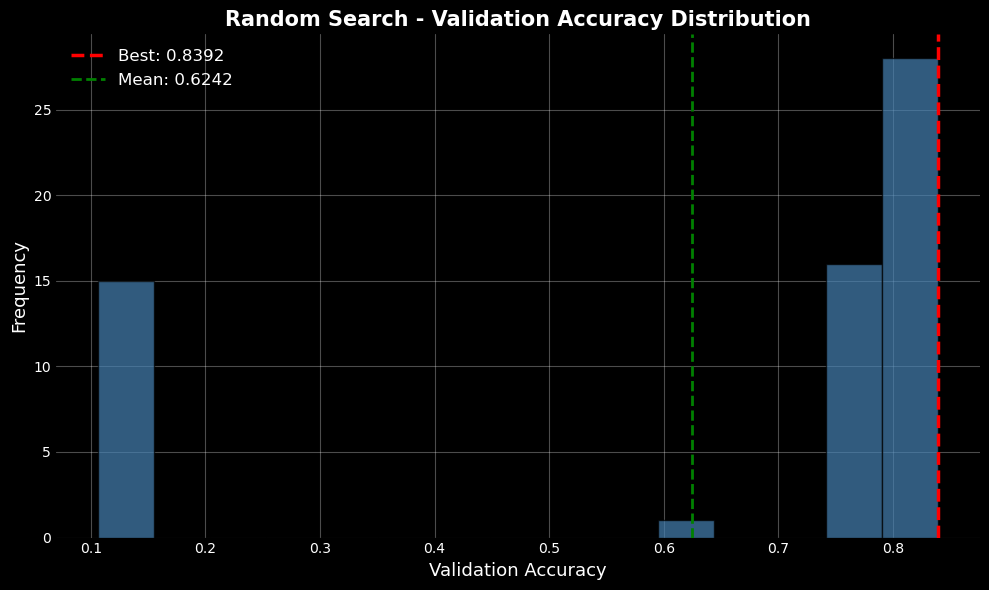

✓ Saved: accuracy_distribution.png


In [10]:
# 1. Validation Accuracy Distribution
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(df['val_accuracy'], bins=15, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(best_config['val_accuracy'], color='red', linestyle='--',
           linewidth=2.5, label=f"Best: {best_config['val_accuracy']:.4f}")
ax.axvline(df['val_accuracy'].mean(), color='green', linestyle='--',
           linewidth=2, label=f"Mean: {df['val_accuracy'].mean():.4f}")

ax.set_xlabel('Validation Accuracy', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
ax.set_title('Random Search - Validation Accuracy Distribution',
             fontsize=15, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('accuracy_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: accuracy_distribution.png")

In [ ]:
# 2. Convergence Progress
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(range(1, 31), cumulative_best, marker='o', linewidth=2.5,
        markersize=7, color='steelblue', label='Best So Far')
ax.plot(range(1, 31), [r['val_accuracy'] for r in results],
        marker='x', linewidth=1, markersize=5, alpha=0.5,
        color='gray', label='Individual Trials')

ax.axhline(best_config['val_accuracy'] * 0.95, color='red',
           linestyle=':', linewidth=2, alpha=0.7, label='95% of Best')

ax.set_xlabel('Trial Number', fontsize=13)
ax.set_ylabel('Validation Accuracy', fontsize=13)
ax.set_title('Random Search Convergence', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('convergence_progress.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: convergence_progress.png")

In [ ]:
# 3. Hyperparameter Impact
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

params = ['dropout_conv', 'dropout_dense', 'learning_rate', 'batch_size', 'patience']

for idx, param in enumerate(params):
    grouped = df.groupby(param)['val_accuracy'].agg(['mean', 'std']).sort_index()

    axes[idx].errorbar(grouped.index, grouped['mean'], yerr=grouped['std'],
                       marker='o', markersize=10, linewidth=2.5, capsize=5,
                       color='steelblue', ecolor='gray')

    axes[idx].set_xlabel(param.replace('_', ' ').title(), fontsize=12)
    axes[idx].set_ylabel('Mean Val Accuracy', fontsize=12)
    axes[idx].set_title(f'{param.replace("_", " ").title()} Impact',
                        fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('hyperparameter_impact.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: hyperparameter_impact.png")

In [ ]:
# 4. Accuracy vs Training Time Scatter
fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df['training_time'], df['val_accuracy'],
                     s=100, alpha=0.6, c=df['val_accuracy'],
                     cmap='viridis', edgecolor='black')

# Highlight best
best_time = best_config['training_time']
best_acc = best_config['val_accuracy']
ax.scatter([best_time], [best_acc], s=400, marker='*',
           color='red', edgecolor='black', linewidth=2,
           label='Best Configuration', zorder=5)

ax.set_xlabel('Training Time (seconds)', fontsize=13)
ax.set_ylabel('Validation Accuracy', fontsize=13)
ax.set_title('Accuracy vs Training Time', fontsize=15, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.colorbar(scatter, ax=ax, label='Validation Accuracy')
plt.tight_layout()
plt.savefig('accuracy_vs_time.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: accuracy_vs_time.png")

## 11. Train Final Model with Best Hyperparameters

In [ ]:
print("\n" + "="*70)
print("TRAINING FINAL MODEL WITH OPTIMIZED HYPERPARAMETERS")
print("="*70)

final_params = best_config['params']
print("\nOptimal Hyperparameters:")
for key, value in final_params.items():
    print(f"  {key:20s}: {value}")

print("\nTraining final model...")
final_result = train_and_evaluate(final_params, verbose=1)

In [ ]:
# Final results summary
print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE")
print("="*70)
print(f"\nValidation Accuracy: {final_result['val_accuracy']:.4f}")
print(f"Test Accuracy:       {final_result['test_accuracy']:.4f}")
print(f"Test Loss:           {final_result['test_loss']:.4f}")
print(f"\nTraining Accuracy:   {final_result['train_accuracy']:.4f}")
print(f"Overfitting Gap:     {final_result['overfitting_gap']:.4f}")
print(f"\nEpochs Trained:      {final_result['epochs_trained']}")
print(f"Training Time:       {final_result['training_time']:.1f}s")
print("="*70)

# Compare with baseline from Part B
print("\n" + "="*70)
print("COMPARISON WITH BASELINE (Part B)")
print("="*70)
baseline_acc = 0.00  # Fill with your Part B result
improvement = (final_result['test_accuracy'] - baseline_acc) * 100

print(f"Baseline (Part B default):  {baseline_acc:.4f}")
print(f"Optimized (Random Search):  {final_result['test_accuracy']:.4f}")
print(f"\nImprovement: +{improvement:.2f}%")
print("="*70)

In [ ]:
# Plot final model training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(final_result['history']['accuracy'], label='Training', linewidth=2)
axes[0].plot(final_result['history']['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Final Model Training - Accuracy', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(final_result['history']['loss'], label='Training', linewidth=2)
axes[1].plot(final_result['history']['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Final Model Training - Loss', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('final_model_training.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved: final_model_training.png")

## 12. Save All Results

In [ ]:
# Create summary dictionary
summary = {
    'experiment_info': {
        'method': 'Random Search',
        'dataset': 'CIFAR-10',
        'trials': 30,
        'search_space_size': 768,
        'coverage': 3.9,
        'total_time_seconds': search_time,
        'random_seed': 42
    },
    'best_configuration': {
        'hyperparameters': best_config['params'],
        'validation_accuracy': float(best_config['val_accuracy']),
        'test_accuracy': float(best_config['test_accuracy']),
        'training_time': float(best_config['training_time']),
        'epochs_trained': int(best_config['epochs_trained'])
    },
    'statistics': {
        'mean_val_accuracy': float(df['val_accuracy'].mean()),
        'std_val_accuracy': float(df['val_accuracy'].std()),
        'min_val_accuracy': float(df['val_accuracy'].min()),
        'max_val_accuracy': float(df['val_accuracy'].max()),
        'range': float(df['val_accuracy'].max() - df['val_accuracy'].min())
    },
    'final_model': {
        'validation_accuracy': float(final_result['val_accuracy']),
        'test_accuracy': float(final_result['test_accuracy']),
        'test_loss': float(final_result['test_loss']),
        'overfitting_gap': float(final_result['overfitting_gap']),
        'epochs': int(final_result['epochs_trained']),
        'training_time': float(final_result['training_time'])
    }
}

# Save to JSON
with open('random_search_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("\n" + "="*70)
print("EXPERIMENT COMPLETED SUCCESSFULLY")
print("="*70)
print("\nGenerated Files:")
print("  1. random_search_results.csv       - All 30 trial results")
print("  2. hyperparameter_importance.csv   - Importance ranking")
print("  3. random_search_summary.json      - Complete summary")
print("  4. accuracy_distribution.png       - Accuracy histogram")
print("  5. convergence_progress.png        - Search convergence")
print("  6. hyperparameter_impact.png       - Impact analysis")
print("  7. accuracy_vs_time.png            - Efficiency scatter")
print("  8. final_model_training.png        - Training curves")
print("\n" + "="*70)
print(f"\nBest Configuration Achieved:")
print(f"  Test Accuracy: {final_result['test_accuracy']:.4f}")
print(f"  Found in trial: {np.argmax([r['val_accuracy'] for r in results]) + 1}/30")
print("="*70)